In [1]:
from sklearn.metrics import classification_report, confusion_matrix
from imblearn.over_sampling import RandomOverSampler
import matplotlib.pyplot as plt
from collections import Counter
from sklearn.svm import SVC
import seaborn as sns
import pandas as pd
import joblib
import os

In [2]:
FILE_PATH = '../../../../cyberbullying_tweets_classifiers.csv'
df = pd.read_csv(FILE_PATH)
df = df.dropna(how='any')
df.head()

,text,type,label
0,rape realzvasiyana enema joke drunk gay lesbia...,gender,0
1,never saw celebrity say anything like obama b ...,gender,0
2,user mean gay us gendered slur make rape joke,gender,0
3,between user user user user feminacy,gender,0
4,rape rape fact read one post guy getting raped...,gender,0


In [3]:
label_to_type = df.groupby('label')['type'].first().to_dict()
target_names = [label_to_type[i] for i in sorted(label_to_type.keys())]

In [14]:
base_path = "../../../../Embeddings/TF-IDF/Data"

X_train = joblib.load(os.path.join(base_path, "X_train_tfidf_2.pkl"))
X_test = joblib.load(os.path.join(base_path, "X_test_tfidf_2.pkl"))
y_train = joblib.load(os.path.join(base_path, "y_train_tfidf_2.pkl"))
y_test = joblib.load(os.path.join(base_path, "y_test_tfidf_2.pkl"))
tfidf_vectorizer = joblib.load(os.path.join(base_path,"tfidf_vectorizer2.pkl"))

In [5]:
print("Distribuție înainte de oversampling:", Counter(y_train))

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Distribuție după oversampling:", Counter(y_train_resampled))

Distribuție înainte de oversampling: Counter({1: 6369, 3: 6308, 4: 6251, 0: 6191, 2: 5943})
Distribuție după oversampling: Counter({1: 6369, 3: 6369, 2: 6369, 4: 6369, 0: 6369})


In [6]:
svm_model = SVC(kernel='linear', random_state=42)

In [7]:
svm_model.fit(X_train_resampled, y_train_resampled)
y_pred = svm_model.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.92      0.88      0.90      1548
           religion       0.99      0.96      0.97      1592
other_cyberbullying       0.80      0.92      0.86      1486
                age       0.99      0.98      0.98      1577
          ethnicity       0.99      0.94      0.96      1563

           accuracy                           0.93      7766
          macro avg       0.94      0.93      0.93      7766
       weighted avg       0.94      0.93      0.94      7766



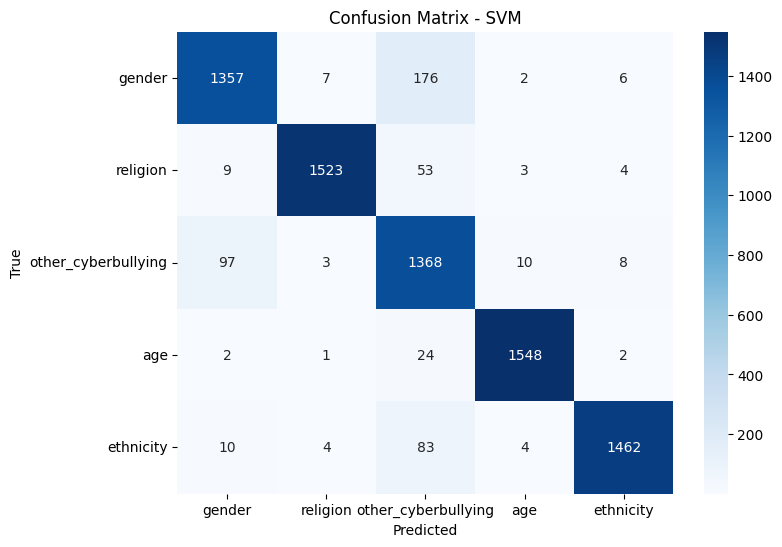

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM')
plt.show()

In [17]:
texts = [
    "You are muslim you don't have opinion",
    "You are just a little girl!",
    "Nigga",
    "Boy"
]

texts_vect = tfidf_vectorizer.transform(texts).toarray()

# Predicție
labels_pred = svm_model.predict(texts_vect)

# Afișare rezultat
for text, label in zip(texts, labels_pred):
    print(f"Text: {text}\nPredicted type: {label_to_type[label]}\n")

Text: You are muslim you don't have opinion
Predicted type: religion

Text: You are just a little girl!
Predicted type: other_cyberbullying

Text: Nigga
Predicted type: other_cyberbullying

Text: Boy
Predicted type: other_cyberbullying



In [18]:
joblib.dump(svm_model, "svm_model_tfidf.pkl")

['svm_model_tfidf.pkl']

GloVe

In [4]:
base_path = "../../../../Embeddings/GloVe/Data"

X_train = joblib.load(os.path.join(base_path, "X_train_glove.pkl"))
X_test = joblib.load(os.path.join(base_path, "X_test_glove.pkl"))
y_train = joblib.load(os.path.join(base_path, "y_train_glove.pkl"))
y_test = joblib.load(os.path.join(base_path, "y_test_glove.pkl"))

In [5]:
print("Distribuție înainte de oversampling:", Counter(y_train))

ros = RandomOverSampler(random_state=42)
X_train_resampled, y_train_resampled = ros.fit_resample(X_train, y_train)

print("Distribuție după oversampling:", Counter(y_train_resampled))

Distribuție înainte de oversampling: Counter({1: 6369, 3: 6310, 4: 6254, 0: 6205, 2: 5998})
Distribuție după oversampling: Counter({1: 6369, 2: 6369, 4: 6369, 3: 6369, 0: 6369})


In [6]:
svm_model = SVC(kernel='linear', random_state=42)

In [7]:
svm_model.fit(X_train_resampled, y_train_resampled)
y_pred = svm_model.predict(X_test)

In [8]:
print(classification_report(y_test, y_pred, target_names=target_names))

                     precision    recall  f1-score   support

             gender       0.84      0.81      0.83      1552
           religion       0.95      0.93      0.94      1592
other_cyberbullying       0.73      0.80      0.76      1500
                age       0.96      0.96      0.96      1577
          ethnicity       0.94      0.90      0.92      1563

           accuracy                           0.88      7784
          macro avg       0.88      0.88      0.88      7784
       weighted avg       0.88      0.88      0.88      7784



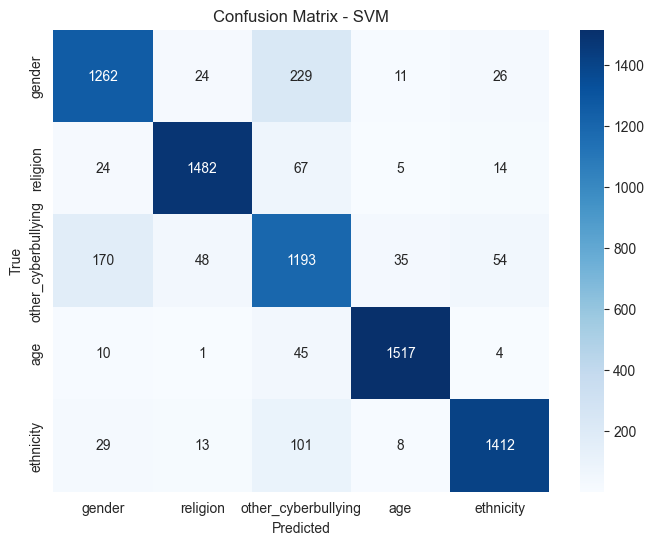

In [9]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix - SVM')
plt.show()